# Import libraries

In [1]:
import os
import pandas as pd
import numpy as np
from ICU_helpers.data_cleaning import *
from ICU_helpers.surgery_mapping import *

# Import data

In [2]:
df = pd.read_excel("../Nkhoma_data/ICU_research.xlsx")

# Clean Data

In [3]:
df = (
    df
    .pipe(to_snake_case)
    .pipe(drop_empty_rows)
    .pipe(drop_unnamed_index)
    .pipe(format_dates)
    .pipe(format_gender)
    .pipe(format_age)
    .pipe(format_stay_durations)
    .pipe(format_intubation)
    .pipe(format_qsofa)
    .pipe(format_categoricals)
    .pipe(add_derived_columns)
    .pipe(map_surgeries)
)

In [4]:
df.columns

Index(['year_of_birth', 'gender', 'hospital_admission_date',
       'hospital_discharge_date', 'date_of_surgery', 'type_of_surgery',
       'icu_admission_date', 'icu_discharge_date', 'intubation',
       'date_of_intubation', 'date_of_extubation', 'niv', 'type_of_admission',
       'lead_department', 'reason_for_admission_category',
       'reason_for_admission_comment', 'diagnosis_that_lead_to_admission',
       'other_diagnoses', 'other_diagnoses_free_text',
       'disability_at_discharge', 'cause_of_death', 'discharge_to', 'qsofa',
       'length_of_icu_stay_nights', 'intubation_nights',
       'hospital_stay_nights', 'discharge_after_icu_nights', 'age_years',
       'comment', 'icu_stay_check', 'hosp_stay_check',
       'type_of_surgery_grouped'],
      dtype='object')

In [5]:
df.type_of_surgery_grouped.unique()

array(['Hemi/Total Thyroidectomy', 'Other', 'EGD', 'Chest Tube Placement',
       'Exploratory Laparotomy', 'No Surgery', 'Hysterectomy',
       'Open Prostatectomy',
       'Exploratory Laparotomy with Bowel Resection', 'Debridement',
       'Caesarean Section', 'Laparoscopic Cholecystectomy', nan,
       'Exploratory Laparotomy with Splenectomy'], dtype=object)

In [6]:
df

,year_of_birth,gender,hospital_admission_date,hospital_discharge_date,date_of_surgery,type_of_surgery,icu_admission_date,icu_discharge_date,intubation,date_of_intubation,...,qsofa,length_of_icu_stay_nights,intubation_nights,hospital_stay_nights,discharge_after_icu_nights,age_years,comment,icu_stay_check,hosp_stay_check,type_of_surgery_grouped
0,1944.0,Male,2023-07-24,2023-07-27,2023-07-26,Hemithyroidectomy,2023-07-25,2023-07-26,Yes,2023-07-26,...,<NA>,1.0,0.0,3.0,1.0,79,NaN,False,False,Hemi/Total Thyroidectomy
1,1988.0,Male,2023-07-14,2023-08-21,2023-08-17,Buccal Graft Urethroplasty,2023-08-17,2023-08-20,Yes,2023-08-17,...,<NA>,3.0,1.0,38.0,1.0,35,NaN,False,False,Other
2,1977.0,Female,2023-08-12,2023-08-18,NaT,EGD,2023-08-17,2023-08-18,No,NaT,...,3,1.0,0.0,6.0,0.0,46,NaN,False,False,EGD
3,2010.0,Female,2023-07-31,2023-08-08,2023-07-31,Chest Tube Placement,2023-07-31,2023-08-05,No,NaT,...,<NA>,5.0,0.0,8.0,3.0,13,NaN,False,False,Chest Tube Placement
4,1972.0,Male,2023-08-10,2023-08-12,2023-08-10,EGD And Banding,2023-08-10,2023-08-11,No,NaT,...,<NA>,1.0,0.0,2.0,1.0,51,NaN,False,False,EGD
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
142,2006.0,Male,2024-12-06,2024-12-09,NaT,No Surgery,2024-12-06,2024-12-07,No,NaT,...,<NA>,1.0,0.0,3.0,2.0,17,NaN,False,False,No Surgery
143,2005.0,Female,2024-12-21,2024-12-28,2024-12-23,Ex Lap,2024-12-23,2024-12-24,Yes,NaT,...,<NA>,1.0,0.0,7.0,4.0,18,NaN,False,False,Exploratory Laparotomy
144,2002.0,Female,2024-12-23,2024-12-26,2024-12-24,Cessarian Section,2024-12-23,2024-12-26,No,NaT,...,1,3.0,0.0,3.0,0.0,21,NaN,False,False,Caesarean Section
145,2022.0,Male,2024-12-27,2024-12-29,2024-12-29,NaN,2024-12-27,2024-12-29,No,NaT,...,2,2.0,0.0,2.0,0.0,1,NaN,False,False,NaN


# ICU Data Assessment
**Date:** 05.05.2026  
**Patients:** 141 admissions (2023–2024)

In [7]:
df['lead_department'] = df['lead_department'].str.strip().str.replace(' ', '_')
df_outliers = df[~df['age_years'].between(0, 150)]
df = df[df['age_years'].between(0, 150)]
df = df.copy()

df['died_on_icu'] = df['discharge_to'] == 'Death'
df['was_intubated'] = df['intubation'] == 'Yes'

df['discharge_category'] = df['discharge_to'].map({
    'Ward': 'Ward',
    'Death': 'Death',
    'Kch': 'Referral',
    'Home': 'Home'
}).fillna('Unknown')

def intubation_group(row):
    if row['intubation'] == 'No':
        return 'Not intubated'
    elif pd.notna(row['date_of_intubation']) and row['date_of_intubation'] > row['icu_admission_date']:
        return 'Intubated on ICU'
    else:
        return 'Intubated outside ICU'

df['intubation_group'] = df.apply(intubation_group, axis=1)

print(f"Shape: {df.shape}")

Shape: (147, 36)


In [8]:
# How many are same-day?
same_day = df[
    (df['intubation'] == 'Yes') &
    (df['date_of_intubation'] == df['icu_admission_date'])
]
print(same_day.shape[0])

38


## 1. Bed Occupancy
How many days had 0, 1, 2, 3, or 4+ ICU beds occupied simultaneously?  
Calculated by counting patients where `icu_admission_date ≤ day ≤ icu_discharge_date`.

In [9]:
import pandas as pd

all_days = pd.date_range(
    start=df['icu_admission_date'].min(),
    end=df['icu_discharge_date'].max(),
    freq='D'
)

def count_occupied(day):
    return ((df['icu_admission_date'] <= day) & (df['icu_discharge_date'] >= day)).sum()

occupancy = pd.Series({day: count_occupied(day) for day in all_days}, name='beds_occupied')
occ_dist = occupancy.value_counts().sort_index()
print(occ_dist)

beds_occupied
0    224
1    189
2     86
3     22
4      4
Name: count, dtype: int64


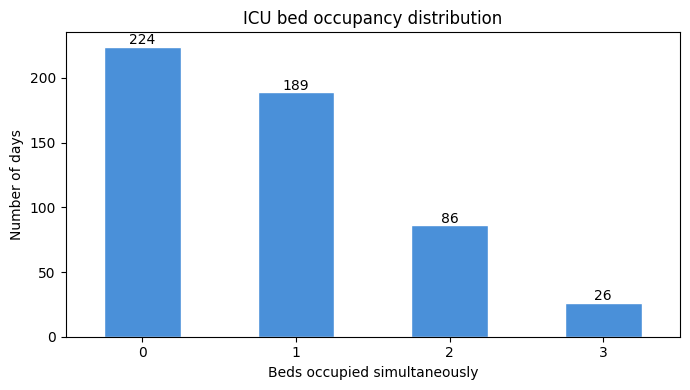

In [10]:
import matplotlib.pyplot as plt

# ── Bucket: anything >= 3 → "3+" ─────────────────────────────────────
occ_bucketed = occ_dist.copy()
occ_bucketed.index = occ_bucketed.index.map(lambda x: '3' if x >= 3 else str(x))
occ_bucketed = occ_bucketed.groupby(occ_bucketed.index, sort=False).sum()

# Preserve order: 0, 1, 2, 3+
order = [str(i) for i in range(3)] + ['3']
occ_bucketed = occ_bucketed.reindex([k for k in order if k in occ_bucketed.index])

# ── Plot ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
occ_bucketed.plot(kind='bar', ax=ax, color='#4a90d9', edgecolor='white')
ax.set_xlabel('Beds occupied simultaneously')
ax.set_ylabel('Number of days')
ax.set_title('ICU bed occupancy distribution')
ax.set_xticklabels(occ_bucketed.index, rotation=0)
for i, v in enumerate(occ_bucketed):
    ax.text(i, v + 2, str(v), ha='center', fontsize=10)
plt.tight_layout()
plt.savefig("ICU_plots/01_bed_occupancy_distribution.png", dpi=150, bbox_inches='tight')
plt.savefig("ICU_plots/01_bed_occupancy_distribution.pdf", bbox_inches='tight')
plt.show()

## 2. Deaths by Department
Per reporting convention: a surgical patient who died on the ICU counts as a surgical death.  
This shows what percentage of each department's total ICU patients died on the ICU.

In [11]:
df

,year_of_birth,gender,hospital_admission_date,hospital_discharge_date,date_of_surgery,type_of_surgery,icu_admission_date,icu_discharge_date,intubation,date_of_intubation,...,discharge_after_icu_nights,age_years,comment,icu_stay_check,hosp_stay_check,type_of_surgery_grouped,died_on_icu,was_intubated,discharge_category,intubation_group
0,1944.0,Male,2023-07-24,2023-07-27,2023-07-26,Hemithyroidectomy,2023-07-25,2023-07-26,Yes,2023-07-26,...,1.0,79,NaN,False,False,Hemi/Total Thyroidectomy,False,True,Ward,Intubated on ICU
1,1988.0,Male,2023-07-14,2023-08-21,2023-08-17,Buccal Graft Urethroplasty,2023-08-17,2023-08-20,Yes,2023-08-17,...,1.0,35,NaN,False,False,Other,False,True,Ward,Intubated outside ICU
2,1977.0,Female,2023-08-12,2023-08-18,NaT,EGD,2023-08-17,2023-08-18,No,NaT,...,0.0,46,NaN,False,False,EGD,True,False,Death,Not intubated
3,2010.0,Female,2023-07-31,2023-08-08,2023-07-31,Chest Tube Placement,2023-07-31,2023-08-05,No,NaT,...,3.0,13,NaN,False,False,Chest Tube Placement,False,False,Ward,Not intubated
4,1972.0,Male,2023-08-10,2023-08-12,2023-08-10,EGD And Banding,2023-08-10,2023-08-11,No,NaT,...,1.0,51,NaN,False,False,EGD,False,False,Ward,Not intubated
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
142,2006.0,Male,2024-12-06,2024-12-09,NaT,No Surgery,2024-12-06,2024-12-07,No,NaT,...,2.0,17,NaN,False,False,No Surgery,False,False,Ward,Not intubated
143,2005.0,Female,2024-12-21,2024-12-28,2024-12-23,Ex Lap,2024-12-23,2024-12-24,Yes,NaT,...,4.0,18,NaN,False,False,Exploratory Laparotomy,False,True,Ward,Intubated outside ICU
144,2002.0,Female,2024-12-23,2024-12-26,2024-12-24,Cessarian Section,2024-12-23,2024-12-26,No,NaT,...,0.0,21,NaN,False,False,Caesarean Section,False,False,Referral,Not intubated
145,2022.0,Male,2024-12-27,2024-12-29,2024-12-29,NaN,2024-12-27,2024-12-29,No,NaT,...,0.0,1,NaN,False,False,NaN,False,False,Ward,Not intubated


In [12]:
# Do the same but with the ward admission

In [13]:
dept_summary = df.groupby('lead_department').agg(
    total_patients=('died_on_icu', 'count'),
    icu_deaths=('died_on_icu', 'sum')
).assign(
    mortality_pct=lambda x: (x['icu_deaths'] / x['total_patients'] * 100).round(1)
).sort_values('mortality_pct', ascending=False)

dept_summary

,total_patients,icu_deaths,mortality_pct
lead_department,,,
Pediatrics,7,2,28.6
Internal_Medicine,21,5,23.8
Gen_Surg,83,16,19.3
Gen_Surg_Trauma,20,2,10.0
Obs_Gyn,16,0,0.0


## 3. Visualisations

### 3a. Intubation status

In [14]:
df['intubation_group'].value_counts()

intubation_group
Not intubated            99
Intubated outside ICU    44
Intubated on ICU          4
Name: count, dtype: int64

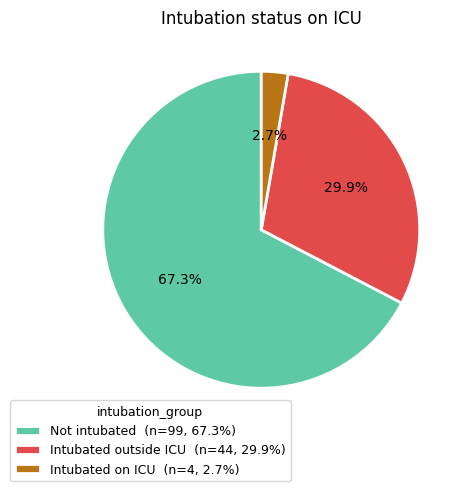

In [15]:
intub_counts = df['intubation_group'].value_counts()
total = intub_counts.sum()

fig, ax = plt.subplots(figsize=(7, 5))
colors = ['#5dcaa5', '#e24b4a', '#ba7517']

wedges, texts, autotexts = ax.pie(
    intub_counts,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

# Build legend labels with count and percentage
legend_labels = [
    f"{label}  (n={count}, {count/total*100:.1f}%)"
    for label, count in zip(intub_counts.index, intub_counts.values)
]

ax.legend(
    wedges,
    legend_labels,
    title="intubation_group",
    loc="lower left",
    bbox_to_anchor=(-0.15, -0.15),
    fontsize=9,
    title_fontsize=9,
    frameon=True
)

ax.set_title('Intubation status on ICU')
plt.tight_layout()
plt.savefig("ICU_plots/02_intubation_status.png", dpi=150, bbox_inches='tight')
plt.savefig("ICU_plots/02_intubation_status.pdf", bbox_inches='tight')

plt.show()

### 3b. ICU patients per department

In [16]:
# General surgery trauma and General surgery is the same TODO

In [17]:
print("trauma_keys:", trauma_keys)
print("gs_keys:", gs_keys)
print("dept before drop:\n", dept)
print("dept after drop and recombine:\n", dept)
print("total:", dept.sum())

NameError: name 'trauma_keys' is not defined

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

dept = df['lead_department'].value_counts().copy()

trauma_keys = [k for k in dept.index if 'trauma' in k.lower()]
gs_keys     = [k for k in dept.index if ('gen_surg' in k.lower() or 
               ('general' in k.lower() and 'surgery' in k.lower()))
               and k not in trauma_keys]  # ← exclude trauma keys

trauma_val   = sum(dept.get(k, 0) for k in trauma_keys)
gs_val       = sum(dept.get(k, 0) for k in gs_keys)
combined_val = gs_val + trauma_val
combined_label = 'Gen_Surg\n(incl. Trauma)'
dept = df['lead_department'].value_counts().copy()
dept = dept.drop(labels=gs_keys + trauma_keys, errors='ignore')
dept[combined_label] = combined_val
dept = dept.sort_values(ascending=False)

total = dept.sum()

# ── Distinct colours for each department ─────────────────────────────
PALETTE = ['#4a90d9', '#e07b39', '#4caf7d', '#9b59b6', '#e74c3c',
           '#f0c419', '#1abc9c', '#e91e63', '#607d8b']
colors = {lbl: PALETTE[i % len(PALETTE)] for i, lbl in enumerate(dept.index)}
gs_color = colors[combined_label]   # whatever colour GS got

def make_autopct(values):
    def autopct(pct):
        n = int(round(pct * total / 100.0))
        return f"{pct:.1f}%\n(n={n})"
    return autopct

# ── Plot ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 7))

wedges, texts, autotexts = ax.pie(
    dept.values,
    labels=None,
    autopct=make_autopct(dept.values),
    colors=[colors[lbl] for lbl in dept.index],
    startangle=90,
    counterclock=False,
    wedgeprops=dict(edgecolor='white', linewidth=1.5),
    pctdistance=0.72,
)
for at in autotexts:
    at.set_fontsize(8)

# ── Dotted divider INSIDE the General Surgery wedge ──────────────────
# Draw a dashed radius line that splits GS from Trauma proportionally
gs_idx   = list(dept.index).index(combined_label)
wedge    = wedges[gs_idx]
theta1   = np.deg2rad(wedge.theta1)   # start angle of the combined wedge
theta2   = np.deg2rad(wedge.theta2)   # end angle

# The split sits at the angle proportional to gs_val within the combined wedge
# (going counterclock=False means angles decrease)
span      = theta2 - theta1           # negative if clockwise
split_theta = theta1 + span * (gs_val / combined_val)

# Draw dashed line from centre to rim at split angle
r = 1.0   # rim radius in axes units
ax.plot([0, r * np.cos(split_theta)],
        [0, r * np.sin(split_theta)],
        linestyle='--', color='white', linewidth=1.8, zorder=5)

# Small label indicating the split
mid_gs     = theta1 + span * (gs_val / combined_val / 2)
mid_trauma = split_theta + span * ((combined_val - gs_val) / combined_val / 2)
ax.text(0.45 * np.cos(mid_gs),     0.45 * np.sin(mid_gs),
        f"Gen_Surg\nn={int(gs_val)}",
        ha='center', va='center', fontsize=6.5, color='white', fontweight='bold')
ax.text(0.45 * np.cos(mid_trauma), 0.45 * np.sin(mid_trauma),
        f"Trauma\nn={int(trauma_val)}",
        ha='center', va='center', fontsize=6.5, color='white', fontweight='bold')

# ── Legend ────────────────────────────────────────────────────────────
legend_labels = list(dept.index)
legend_colors = [colors[lbl] for lbl in legend_labels]
handles = [mpatches.Patch(color=c, label=l)
           for c, l in zip(legend_colors, legend_labels)]
ax.legend(handles=handles,
          loc='lower center', bbox_to_anchor=(0.5, -0.15),
          ncol=min(len(dept), 3), fontsize=8,
          frameon=True, framealpha=0.9)

ax.set_title(f'ICU admissions by department  (N={total})', fontweight='bold')
plt.tight_layout()
plt.savefig("ICU_plots/03_ICU_patients_per_department.png", dpi=150, bbox_inches='tight')
plt.savefig("ICU_plots/03_ICU_patients_per_department.pdf", bbox_inches='tight')
plt.show()

In [ ]:
# TODO pie chart, General surgery (including Trauma) with the numbers dotted line

### 3c. Procedures and ICU stay

In [ ]:
proc = df.groupby('type_of_surgery_grouped').agg(
    patients=('type_of_surgery_grouped', 'count'),
    avg_icu_nights=('length_of_icu_stay_nights', 'mean')
).sort_values('patients', ascending=True).round(1)

fig, ax1 = plt.subplots(figsize=(8, 6))
bars = ax1.barh(proc.index, proc['patients'], color='#4a90d9', edgecolor='white')
ax1.set_xlabel('Patients')
ax1.set_title('Procedures and ICU stay')

ax2 = ax1.twiny()
ax2.plot(proc['avg_icu_nights']+1, proc.index, 'o-', color='#e24b4a', linewidth=1.5, markersize=5)
ax2.set_xlabel('Avg ICU days', color='#e24b4a')
ax2.tick_params(axis='x', colors='#e24b4a')

plt.tight_layout()
plt.savefig("ICU_plots/04_procedures_and_ICU_stay.png", dpi=150, bbox_inches='tight')
plt.savefig("ICU_plots/04_procedures_and_ICU_stay.pdf", bbox_inches='tight')

plt.show()

### 3d. ICU discharge destinations

In [ ]:
# Move the 2.1 for readability TODO

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

discharge_counts = df['discharge_category'].value_counts()
total = discharge_counts.sum()
colors = {'Ward': '#5dcaa5', 'Death': '#e24b4a', 'Referral': '#ba7517',
          'Home': '#4a90d9', 'Unknown': '#888780'}

# Explode small slices (< 5%) outward so their labels have room
explode = [0.12 if (v / total * 100) < 5 else 0
           for v in discharge_counts.values]

fig, ax = plt.subplots(figsize=(7, 5))
wedges, texts, autotexts = ax.pie(
    discharge_counts,
    autopct='%1.1f%%',
    colors=[colors.get(k, '#888780') for k in discharge_counts.index],
    startangle=90,
    explode=explode,
    pctdistance=0.75,       # pull % labels slightly inward
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

# Move autotext for any slice < 5% further out so it clears neighbours
for at, v in zip(autotexts, discharge_counts.values):
    if v / total * 100 < 5:
        x, y = at.get_position()
        r = np.hypot(x, y)
        at.set_position((x / r * 1.15, y / r * 1.15))
        at.set_fontsize(8)

legend_labels = [
    f"{label}  (n={count}, {count/total*100:.1f}%)"
    for label, count in zip(discharge_counts.index, discharge_counts.values)
]
ax.legend(
    wedges, legend_labels,
    title="discharge_category",
    loc="lower left",
    bbox_to_anchor=(-0.15, -0.15),
    fontsize=9, title_fontsize=9,
    frameon=True
)
ax.set_title('ICU discharge destinations')
plt.tight_layout()
plt.savefig("ICU_plots/5_ICU_discharge_destinations.png", dpi=150, bbox_inches='tight')
plt.savefig("ICU_plots/5_ICU_discharge_destinations.pdf", bbox_inches='tight')
plt.show()

## 4. Patterns in the Data

### 4a. ICU length of stay by intubation group

In [ ]:
import matplotlib.pyplot as plt

# ── Stats table ───────────────────────────────────────────────────────
stats = (df.groupby('intubation_group')['length_of_icu_stay_nights']
           .describe()[['count', 'mean', '25%', '50%', '75%', 'max']]
           .round(1)
           .rename(columns={'50%': 'median', '25%': 'Q1', '75%': 'Q3'}))

groups = ['Not intubated', 'Intubated on ICU', 'Intubated outside ICU']
colors = ['#5dcaa5', '#e24b4a', '#ba7517']
data   = [df.loc[df['intubation_group'] == g,
                 'length_of_icu_stay_nights'].dropna()
          for g in groups]

# ── Figure ────────────────────────────────────────────────────────────
fig, (ax, tax) = plt.subplots(2, 1, figsize=(9, 7),
                               gridspec_kw={'height_ratios': [3, 1]})

# --- Boxplot ---
bp = ax.boxplot(
    data,
    patch_artist=True,
    medianprops=dict(color='black', linewidth=2),
    whiskerprops=dict(linewidth=1.5),
    capprops=dict(linewidth=1.5),
    flierprops=dict(marker='o', markersize=4, linestyle='none', markeredgewidth=0.8)
)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.85)
for flier, color in zip(bp['fliers'], colors):
    flier.set(markerfacecolor=color, markeredgecolor=color)

ax.set_xticks([1, 2, 3])
ax.set_xticklabels(groups, fontsize=10)
ax.set_title('ICU stay by intubation group', fontsize=12, pad=12)
ax.set_ylabel('Nights', fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# --- Table ---
tax.axis('off')
table_data = [
    [int(stats.loc[g, 'count']), stats.loc[g, 'mean'],
     stats.loc[g, 'Q1'], stats.loc[g, 'median'],
     stats.loc[g, 'Q3'], stats.loc[g, 'max']]
    for g in groups
]
table = tax.table(
    cellText=table_data,
    rowLabels=groups,
    colLabels=['n', 'Mean', 'Q1', 'Median', 'Q3', 'Max'],
    loc='center',
    cellLoc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.6)

for i, color in enumerate(colors):
    table[(i + 1, -1)].set_facecolor(color)
    table[(i + 1, -1)].set_alpha(0.4)

plt.tight_layout()
plt.savefig("ICU_plots/06_icu_stay_by_intubation.png", dpi=150, bbox_inches='tight')
plt.savefig("ICU_plots/06_icu_stay_by_intubation.pdf", bbox_inches='tight')
plt.show()

### 4b. Mortality by intubation group
Non-intubated patients had the highest mortality — likely reflecting late presentations and palliated cases.

In [ ]:
mort_intub = df.groupby('intubation_group').agg(
    patients=('died_on_icu', 'count'),
    deaths=('died_on_icu', 'sum')
).assign(mortality_pct=lambda x: (x['deaths'] / x['patients'] * 100).round(1))

fig, (ax, tax) = plt.subplots(2, 1, figsize=(7, 6),
                               gridspec_kw={'height_ratios': [3, 1]})

# --- Bar chart ---
colors = ['#e24b4a', '#ba7517', '#5dcaa5']
bars = ax.bar(range(len(mort_intub)), mort_intub['mortality_pct'],
              color=colors, edgecolor='white', linewidth=1.5, alpha=0.85)

for i, v in enumerate(mort_intub['mortality_pct']):
    ax.text(i, v + 0.5, f'{v}%', ha='center', fontsize=10, fontweight='bold')

ax.set_xticks(range(len(mort_intub)))
ax.set_xticklabels(mort_intub.index, rotation=15, ha='right', fontsize=10)
ax.set_ylabel('Mortality %', fontsize=10)
ax.set_title('ICU mortality by intubation group', fontsize=12, pad=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylim(0, mort_intub['mortality_pct'].max() + 8)

# --- Table ---
tax.axis('off')

table_data = [
    [int(mort_intub.loc[g, 'patients']),
     int(mort_intub.loc[g, 'deaths']),
     f"{mort_intub.loc[g, 'mortality_pct']}%"]
    for g in mort_intub.index
]

table = tax.table(
    cellText=table_data,
    rowLabels=list(mort_intub.index),
    colLabels=['Patients (n)', 'Deaths (n)', 'Mortality %'],
    loc='center',
    cellLoc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.6)

for i, color in enumerate(colors):
    table[(i + 1, -1)].set_facecolor(color)
    table[(i + 1, -1)].set_alpha(0.4)

plt.tight_layout()
plt.savefig("ICU_plots/07_mortality_by_intubation.png", dpi=150, bbox_inches='tight')
plt.savefig("ICU_plots/07_mortality_by_intubation.pdf", bbox_inches='tight')

plt.show()

print(mort_intub)

### 4c. qSOFA score and mortality
qSOFA score 3 carries the highest mortality. Validates use of qSOFA as an early warning tool.

In [ ]:
qsofa_mort = df.groupby('qsofa')['died_on_icu'].agg(['sum', 'count']).assign(
    mortality_pct=lambda x: (x['sum'] / x['count'] * 100).round(1)
).rename(columns={'sum': 'deaths', 'count': 'patients'})

fig, (ax, tax) = plt.subplots(2, 1, figsize=(7, 6),
                               gridspec_kw={'height_ratios': [3, 1]})

# --- Bar chart ---
n = len(qsofa_mort)
bars = ax.bar(range(n), qsofa_mort['mortality_pct'],
              color='#e24b4a', edgecolor='white', linewidth=1.5, alpha=0.85)

for i, v in enumerate(qsofa_mort['mortality_pct']):
    ax.text(i, v + 0.5, f'{v}%', ha='center', fontsize=10, fontweight='bold')

ax.set_xticks(range(n))
ax.set_xticklabels(qsofa_mort.index, rotation=0, fontsize=10)
ax.set_ylabel('Mortality %', fontsize=10)
ax.set_xlabel('qSOFA score', fontsize=10)
ax.set_title('Mortality by qSOFA score', fontsize=12, pad=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylim(0, qsofa_mort['mortality_pct'].max() + 8)

# --- Table ---
tax.axis('off')

table_data = [
    [int(qsofa_mort.loc[score, 'patients']),
     int(qsofa_mort.loc[score, 'deaths']),
     f"{qsofa_mort.loc[score, 'mortality_pct']}%"]
    for score in qsofa_mort.index
]

table = tax.table(
    cellText=table_data,
    rowLabels=[f'qSOFA {s}' for s in qsofa_mort.index],
    colLabels=['Patients (n)', 'Deaths (n)', 'Mortality %'],
    loc='center',
    cellLoc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.6)

# Shade row labels by mortality intensity
max_mort = qsofa_mort['mortality_pct'].max()
for i, score in enumerate(qsofa_mort.index):
    intensity = qsofa_mort.loc[score, 'mortality_pct'] / max_mort
    table[(i + 1, -1)].set_facecolor('#e24b4a')
    table[(i + 1, -1)].set_alpha(intensity * 0.6)

plt.tight_layout()
plt.savefig("ICU_plots/08_mortality_by_qsofa.png", dpi=150, bbox_inches='tight')
plt.savefig("ICU_plots/08_mortality_by_qsofa.pdf", bbox_inches='tight')

plt.show()

print(qsofa_mort)

In [ ]:
surgical = df[df['type_of_surgery_grouped'] != 'No Surgery'].shape[0]
print(f"{surgical}/{len(df)} = {surgical/len(df)*100:.1f}%")

In [ ]:
print(f"Total days in dataset: {len(occupancy)}")
print(f"Days with 0 beds: {(occupancy == 0).sum()}")
print(f"Percentage: {(occupancy == 0).sum() / len(occupancy) * 100:.1f}%")

In [ ]:
df[(df['died_on_icu']) & (df['intubation_group'] == 'Not intubated')][
    ['age_years', 'lead_department', 'type_of_surgery_grouped', 'qsofa']
].sort_values('qsofa', ascending=False)

In [ ]:
# What % of No Surgery patients had missing qSOFA?
no_surg = df[df['type_of_surgery_grouped'] == 'No Surgery']
print(no_surg['qsofa'].isna().value_counts())
print(f"Missing qSOFA in No Surgery: {no_surg['qsofa'].isna().mean()*100:.1f}%")

## 5. Summary of Key Findings

| Metric | Value |
|---|---|
| Total ICU admissions | 141 |
| ICU mortality | 25/141 = **17.7%** |
| Referral rate (to KCH) | 14/141 = **9.9%** |
| Intubation rate | 46/141 = **32.6%** |
| Most common procedure | Exploratory Laparotomy (26 cases) |
| Highest dept mortality | Pediatrics **28.6%** |
| qSOFA 3 mortality | **36.8%** |
| Days with 0 beds occupied | 230 / 525 days **(43.8%)** |
| Avg ICU stay (intubated) | **2.9 nights** vs 1.7 (not intubated) |

**Main points:**
- Referral rate 9.9% — predominantly to KCH
- Case mix is 71.6% surgical, dominated by Exploratory Laparotomy
- qSOFA is a valid mortality predictor: score 3 = 36.8% mortality
- 43.8% of days had zero ICU beds occupied — capacity exists
- Non-intubated mortality (21.1%) is explained by a palliated subgroup:
  80% of "No Surgery" deaths had no qSOFA recorded

In [ ]:
# Total deaths (non-null cause_of_death)
total_deaths = df['cause_of_death'].notna().sum()

# ICU deaths: died AND had an ICU admission
icu_deaths = df[df['cause_of_death'].notna() & df['icu_admission_date'].notna()].shape[0]

# Percentage
pct = (icu_deaths / total_deaths * 100) if total_deaths > 0 else 0

print(f"Total deaths:  {total_deaths}")
print(f"ICU deaths:    {icu_deaths}")
print(f"% ICU deaths:  {pct:.1f}%")

In [ ]:
# Died while still in ICU (no icu_discharge_date, or discharge == hospital_discharge)
icu_deaths_inicu = df[
    df['cause_of_death'].notna() & 
    df['icu_discharge_date'].isna()
].shape[0]

In [ ]:
# Check what values discharge_to contains
print(df['discharge_to'].value_counts())
print(df['cause_of_death'].value_counts())

In [ ]:
# Deaths = discharge_to == "Death"
total_deaths = (df['discharge_to'] == 'Death').sum()  # 25

# In-ICU death: no ICU discharge date (never left ICU alive)
icu_deaths = df[
    (df['discharge_to'] == 'Death') & 
    (df['icu_discharge_date'].isna())
].shape[0]

# Post-ICU death: made it out of ICU, died on ward
post_icu_deaths = total_deaths - icu_deaths

print(f"Total deaths:       {total_deaths}")
print(f"In-ICU deaths:      {icu_deaths}  ({icu_deaths/total_deaths*100:.1f}%)")
print(f"Post-ICU deaths:    {post_icu_deaths}  ({post_icu_deaths/total_deaths*100:.1f}%)")
print(f"ICU mortality rate: {total_deaths/len(df)*100:.1f}%  (of all 147 patients)")

In [ ]:
# ── 1. LOAD ───────────────────────────────────────────────────────────────────
df_mort = pd.read_excel("../Nkhoma_data/ICU_mortality.xlsx", header=[0, 1])
 
# ── 2. DROP EMPTY ROWS ────────────────────────────────────────────────────────
df_mort = df_mort.dropna(how="all").copy()
 
# ── 3. DROP ARTIFACT / REDUNDANT COLUMNS ─────────────────────────────────────
# Excel multi-header produces blank duplicate columns; also drop raw BD/BA ratios
# since the % versions carry the same info in a more readable form.
drop_cols = [
    ("Pre-ICU (Jan.2022 - July 2023)", "Death/Admission %.1"),  # blank duplicate
    ("Post-ICU (Aug.2023 - Dec.2024)", "Deaths.1"),             # blank duplicate
    ("Pre-ICU vs. Post ICU",           "95% CI"),               # blank; CI split into Lower/Upper
    ("Pre-ICU vs. Post ICU",           "Relative Risk Ratio"),  # blank; values are in "RR"
    ("Pre-ICU vs. Post ICU",           "Before-Death/Admission (BD/BA)"),  # raw ratio; % kept
    ("Pre-ICU vs. Post ICU",           "After-Death/Admission (AD/AA)"),   # raw ratio; % kept
]
df_mort = df_mort.drop(columns=[c for c in drop_cols if c in df_mort.columns])

# ── 4. FLATTEN MULTI-INDEX → SNAKE_CASE ──────────────────────────────────────
df_mort.columns = ["_".join(str(lvl) for lvl in col).strip() for col in df_mort.columns]
 
rename_map = {
    "Unnamed: 0_level_0_Unnamed: 0_level_1":            "ward",
    "Pre-ICU (Jan.2022 - July 2023)_Admissions":        "pre_admissions",
    "Pre-ICU (Jan.2022 - July 2023)_Deaths":            "pre_deaths",
    "Pre-ICU (Jan.2022 - July 2023)_Death/Admission %": "pre_death_pct",
    "Post-ICU (Aug.2023 - Dec.2024)_Admissions":        "post_admissions",
    "Post-ICU (Aug.2023 - Dec.2024)_Deaths":            "post_deaths",
    "Post-ICU (Aug.2023 - Dec.2024)_Death/Admission %": "post_death_pct",
    "Pre-ICU vs. Post ICU_Change %":                    "change_pct",
    "Pre-ICU vs. Post ICU_BD/BA[%]":                    "pre_death_admission_pct",
    "Pre-ICU vs. Post ICU_AD/AA[%]":                    "post_death_admission_pct",
    "Pre-ICU vs. Post ICU_RR":                          "rr",
    "Pre-ICU vs. Post ICU_log(RR)":                     "log_rr",
    "Pre-ICU vs. Post ICU_SE of log(RR)":               "se_log_rr",
    "Pre-ICU vs. Post ICU_z":                           "z_stat",
    "Pre-ICU vs. Post ICU_Lower 95% CI":                "ci_lower",
    "Pre-ICU vs. Post ICU_Upper 95% CI":                "ci_upper",
    "Pre-ICU vs. Post ICU_p-values (Wald test)":        "p_value",
}
df_mort = df_mort.rename(columns=rename_map)
# Double space in "Change  %" — rename the surviving unmatched column
df_mort = df_mort.rename(columns={"Pre-ICU vs. Post ICU_Change  %": "change_pct"})
df_mort = df_mort.rename(columns={"Pre-ICU vs. Post ICU_P-value": "p_value_old"})
df_mort["p_value"] = pd.to_numeric(df_mort["p_value"], errors="coerce")
# Drop the duplicate p_value column (keep first)
df_mort = df_mort.loc[:, ~df_mort.columns.duplicated()]

# Drop any rows where ward is NaN (trailing empty Excel rows)
df_mort = df_mort.dropna(subset=["ward"]).reset_index(drop=True)

# Replace "-" strings with NaN before casting (Private Ward p-value)
df_mort = df_mort.replace("-", np.nan).infer_objects(copy=False)

# ── 5. SEPARATE TOTAL ROW ─────────────────────────────────────────────────────
df_total = df_mort[df_mort["ward"] == "TOTAL"].copy()
df_mort       = df_mort[df_mort["ward"] != "TOTAL"].reset_index(drop=True)

# ── 6. CAST TYPES ────────────────────────────────────────────────────────────
# Int64 (nullable) handles Private Ward's zero-death rows without coercing to float
int_cols = ["pre_admissions", "pre_deaths", "post_admissions", "post_deaths"]
df_mort[int_cols] = df_mort[int_cols].astype("Int64")
 
float_cols = [
    "pre_death_pct", "post_death_pct", "change_pct",
    "pre_death_admission_pct", "post_death_admission_pct",
    "rr", "log_rr", "se_log_rr", "z_stat",
    "ci_lower", "ci_upper", "p_value",
]
df_mort[float_cols] = df_mort[float_cols].astype(float)
df_mort

In [ ]:
print(df_mort.columns.tolist())

In [ ]:
# 2a. Separate summary row — already done in block 1, but re-doing cleanly
df_total = df_mort[df_mort["ward"] == "TOTAL"].copy()
df_mort  = df_mort[df_mort["ward"] != "TOTAL"].copy().reset_index(drop=True)

# 2b. Private Ward: 0/0 → undefined risk, already NaN from block 1
# Nothing to do — block 1 handled this via replace("-", np.nan)

# 2c. CI columns already split into ci_lower / ci_upper in block 1
# Nothing to do

# 2d. Types already cast in block 1
# Nothing to do

# 2e. Significance flag
df_mort["significant"] = df_mort["p_value"] < 0.05

# 2f. Sanity check
df_mort["pre_death_pct_check"]  = (df_mort["pre_deaths"]  / df_mort["pre_admissions"]  * 100).round(2)
df_mort["post_death_pct_check"] = (df_mort["post_deaths"] / df_mort["post_admissions"] * 100).round(2)

# ── 3. QUICK SUMMARY ─────────────────────────────────────────────────────────
print("=== Cleaned ward-level data ===")
print(df_mort[["ward", "pre_admissions", "pre_deaths", "pre_death_pct",
               "post_admissions", "post_deaths", "post_death_pct",
               "change_pct", "rr", "ci_lower", "ci_upper",
               "p_value", "significant"]].to_string(index=False))

print("\n=== TOTAL row ===")
print(df_total[["ward", "pre_admissions", "pre_deaths",
                "post_admissions", "post_deaths",
                "change_pct", "rr", "ci_lower", "ci_upper",
                "p_value"]].to_string(index=False))

print("\n=== dtypes ===")
print(df_mort.dtypes)

print("\n=== Missing values ===")
print(df_mort.isnull().sum())